# Day 3 Laboratory Exercise: Measuring A Tumour And Trusting The Measurement

This morning's walkthrough segmented one MRI slice, measured the tumour on it,
and scored the result against a radiologist's outline. The overlap was 0.96,
which is close to as good as this kind of method gets.

That slice was chosen because it works. This afternoon you run the same
pipeline over all 844 slices and find out what it does on the ones nobody
picked.

There are two questions, and both have an obvious route that gives the wrong
answer.

The first is how large a tumour is. You have a pipeline that returns an area in
square millimetres and a radiologist's outline for every slice, so for once the
answer is checkable.

The second is whether a model can tell the three tumour types apart. You have
844 slices, three classes, and a convolutional network. The obvious way to
measure how well it does is wrong, and the number it gives is wrong by a wide
enough margin to change what you would tell somebody.

## How To Work Through This

There are eight tasks. Each states a goal, gives you a cell marked
`# YOUR CODE HERE` that names the variables the check expects, and follows it
with a check cell that either confirms your answer or says what it wanted.

Task 1 asks you to notice something and then tells you to set it aside. Do set
it aside. Tasks 2 to 6 are about the other question entirely. The point of the
laboratory exercise arrives in Task 8, and it depends on your having moved on
in between.

The segmentation pipeline and the network are given to you in full, because
this laboratory exercise is not about retyping them. It is about measuring
whether they work.

In [1]:
import os


def core_budget():
    """The number of cores this session may actually use.

    A container is given a share of the host's cores by the scheduler rather
    than a smaller machine, so the host's own count is the wrong number to size
    a thread pool from. PyTorch takes it regardless, which on the Hub means 48
    threads competing for 3 cores, and the switching between them costs far
    more than the parallelism gains. On a machine with no such quota to read,
    its own count is the right number after all.
    """
    try:
        quota, period = open("/sys/fs/cgroup/cpu.max").read().split()
        if quota != "max":
            return max(1, round(int(quota) / int(period)))
    except OSError:
        pass
    return os.cpu_count() or 1


CORES = core_budget()

# The numerical libraries size their thread pools when they are first imported,
# so these have to be set above the imports rather than below them.
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(variable, str(CORES))

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

cv2.setNumThreads(CORES)
torch.set_num_threads(CORES)

DATA_DIR = Path.cwd().parent / "data"
SLICE_DIR = DATA_DIR / "slices"
MASK_DIR = DATA_DIR / "masks"

RANDOM_STATE = 42

# The in-plane resolution the archive records for a 512 by 512 slice.
PIXEL_MM = 0.49

TUMOUR_TYPES = ["glioma", "meningioma", "pituitary"]

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)


def check(condition, success, failure):
    """Report whether a task was completed correctly."""
    print(success if condition else failure)


slices = pd.read_csv(DATA_DIR / "slices.csv", dtype={"patient_id": str})

print("Slices:", len(slices))
print("Patients:", slices["patient_id"].nunique())
print("OpenCV:", cv2.__version__, "| PyTorch:", torch.__version__)
print("Cores available to this session:", CORES)

Slices: 844
Patients: 66
OpenCV: 5.0.0 | PyTorch: 2.11.0
Cores available to this session: 14


## The Tools You Are Given

The next two cells hold the segmentation pipeline from the walkthrough and the
convolutional network for Tasks 7 and 8. Read them, run them, and then leave
them alone. Every one of the eight tasks calls into them rather than changing
them.

The one detail worth noticing now is the reseeding inside `segment_tumour`.
OpenCV's k-means takes its starting centres from a global random number
generator, so without that line the same slice gives a slightly different
answer every time you call it, and no number in this notebook would be stable.

In [2]:
def head_mask(gray):
    """Return the largest connected object above the Otsu threshold."""
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    count, markers = cv2.connectedComponents(mask)
    if count < 2:
        return np.ones(gray.shape, bool)
    sizes = [(markers == label).sum() for label in range(1, count)]
    return markers == int(np.argmax(sizes)) + 1


def segment_tumour(gray, erode_px=35, clusters=3, open_px=5):
    """Segment the brightest region inside the brain and return a boolean mask."""
    cv2.setRNGSeed(RANDOM_STATE)

    inside = cv2.erode(head_mask(gray).astype(np.uint8),
                       cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                                 (erode_px, erode_px))) > 0
    if inside.sum() < clusters:
        return np.zeros(gray.shape, bool)

    blurred = cv2.GaussianBlur(np.where(inside, gray, 0), (5, 5), 0)
    samples = blurred[inside].reshape(-1, 1).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels, centres = cv2.kmeans(samples, clusters, None, criteria, 10,
                                    cv2.KMEANS_PP_CENTERS)

    grouped = np.full(gray.shape, -1, int)
    grouped[inside] = labels.ravel()
    brightest = (grouped == int(np.argmax(centres.ravel()))).astype(np.uint8) * 255
    brightest = cv2.morphologyEx(brightest, cv2.MORPH_OPEN,
                                 np.ones((open_px, open_px), np.uint8))

    contours, _ = cv2.findContours(brightest, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    result = np.zeros(gray.shape, np.uint8)
    if contours:
        cv2.drawContours(result, [max(contours, key=cv2.contourArea)], -1, 255,
                         cv2.FILLED)
    return result > 127


def dice(a, b):
    """Overlap between two boolean masks, from 0 for none to 1 for identical."""
    total = a.sum() + b.sum()
    return 2 * (a & b).sum() / total if total else 0.0


def read_slice(file_name):
    """Return the greyscale slice and the radiologist's mask for one file."""
    gray = cv2.imread(str(SLICE_DIR / file_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(MASK_DIR / file_name.replace(".jpg", ".png")),
                      cv2.IMREAD_GRAYSCALE)
    assert gray is not None and mask is not None, f"could not read {file_name}"
    return gray, mask > 127


print("Segmentation pipeline ready.")

Segmentation pipeline ready.


In [3]:
IMAGE_SIZE = 96
EPOCHS = 60


def pick_device():
    """Use a GPU when the image provides one, and fall back sensibly."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = pick_device()


def load_all_images(size=IMAGE_SIZE):
    """Read every slice once, scaled down to the network's input size."""
    images = np.stack([
        cv2.resize(cv2.imread(str(SLICE_DIR / name), cv2.IMREAD_GRAYSCALE),
                   (size, size))
        for name in slices["file"]
    ]).astype(np.float32) / 255.0
    labels = slices["tumor_type"].map(
        {name: i for i, name in enumerate(TUMOUR_TYPES)}).to_numpy()
    return images, labels


def build_model():
    """A small convolutional network: three convolutions and a linear layer."""
    torch.manual_seed(RANDOM_STATE)
    return nn.Sequential(
        nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.AdaptiveAvgPool2d(4), nn.Flatten(), nn.Linear(64 * 16, 3),
    )


def train_and_score(train_mask, epochs=EPOCHS, verbose=True):
    """Train on the slices the mask selects and score on the rest.

    Returns the accuracy on the training slices, the accuracy on the held out
    slices, and the predictions for the held out slices.
    """
    torch.manual_seed(RANDOM_STATE)
    train_x = torch.tensor(IMAGES[train_mask]).unsqueeze(1)
    train_y = torch.tensor(LABELS[train_mask])
    test_x = torch.tensor(IMAGES[~train_mask]).unsqueeze(1)
    test_y = torch.tensor(LABELS[~train_mask])

    model = build_model().to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_function = nn.CrossEntropyLoss()
    generator = torch.Generator().manual_seed(RANDOM_STATE)

    for epoch in range(epochs):
        model.train()
        order = torch.randperm(len(train_x), generator=generator)
        for start in range(0, len(order), 32):
            batch = order[start:start + 32]
            optimiser.zero_grad()
            loss = loss_function(model(train_x[batch].to(DEVICE)),
                                 train_y[batch].to(DEVICE))
            loss.backward()
            optimiser.step()

    model.eval()
    with torch.no_grad():
        train_pred = model(train_x.to(DEVICE)).argmax(1).cpu().numpy()
        test_pred = model(test_x.to(DEVICE)).argmax(1).cpu().numpy()

    train_accuracy = float((train_pred == train_y.numpy()).mean())
    test_accuracy = float((test_pred == test_y.numpy()).mean())
    if verbose:
        print(f"trained on {train_mask.sum()} slices, tested on "
              f"{(~train_mask).sum()}")
        print(f"training accuracy {train_accuracy:.3f}")
        print(f"test accuracy     {test_accuracy:.3f}")
    return train_accuracy, test_accuracy, test_pred


IMAGES, LABELS = load_all_images()
print("Images loaded:", IMAGES.shape, "| training on", DEVICE)

Images loaded: (844, 96, 96) | training on mps


## Task 1: Count The Slices And Count The Patients

An MRI dataset has two units of observation and they are not interchangeable. A
slice is one image. A patient is a person, who was scanned once and contributed
several slices, all of the same brain with the same tumour.

Build a DataFrame called `profile`, indexed by `tumor_type`, with three columns:

- `slices`, the number of images,
- `patients`, the number of distinct patients, and
- `median_slices`, the median number of slices those patients contributed.

`groupby("tumor_type").agg(...)` gives the first two. For the third, group by
tumour type and patient, take the size, and then take the median within each
tumour type.

In [4]:
profile = slices.groupby("tumor_type").agg(
    slices=("file", "size"),
    patients=("patient_id", "nunique"),
)
profile["median_slices"] = (
    slices.groupby(["tumor_type", "patient_id"]).size()
    .groupby("tumor_type").median()
)

print(profile.to_string())
print("\nAcross the whole dataset:")
print("  slices  ", len(slices))
print("  patients", slices["patient_id"].nunique())
print("  median slices per patient",
      slices.groupby("patient_id").size().median())

            slices  patients  median_slices
tumor_type                                 
glioma         291        22           14.0
meningioma     274        22           14.0
pituitary      279        22           13.5

Across the whole dataset:
  slices   844
  patients 66
  median slices per patient 14.0


In [5]:
check(
    "profile" in dir()
    and len(profile) == 3
    and {"slices", "patients", "median_slices"} <= set(profile.columns)
    and int(profile["slices"].sum()) == 844
    and int(profile["patients"].sum()) == 66,
    "Task 1 complete. 844 slices from 66 patients, 22 per tumour type. Read "
    "the median_slices column before you move on.",
    "Not right yet. Expected a DataFrame called `profile` indexed by "
    "tumor_type, with columns slices, patients, and median_slices, totalling "
    "844 slices and 66 patients.",
)

Task 1 complete. 844 slices from 66 patients, 22 per tumour type. Read the median_slices column before you move on.


### Read That Table Before Continuing

There are 844 images and 66 people. The median patient contributed 14 slices,
so a typical image in this dataset has thirteen siblings showing the same brain
and the same tumour from a slightly different position.

Write that number down, and then set it aside. The next five tasks are about
measuring a tumour and have nothing to do with it.

## Task 2: Check The Images Against What The Archive Claims

The archive's documentation states that every image has an in-plane resolution
of 512 by 512 with pixel dimensions of 0.49 by 0.49 millimetres. The constant
`PIXEL_MM` in this notebook depends on that sentence, and every area you
compute today depends on `PIXEL_MM`.

Documentation is not data. Check it.

Measure the shape of every slice. Count how many are not 512 by 512 into
`n_unusual`, and put the patient identifier or identifiers they belong to in a
sorted list called `unusual_patients`.

In [6]:
shapes = {
    name: cv2.imread(str(SLICE_DIR / name), cv2.IMREAD_GRAYSCALE).shape
    for name in slices["file"]
}

measured = slices.copy()
measured["height"] = measured["file"].map(lambda name: shapes[name][0])
measured["width"] = measured["file"].map(lambda name: shapes[name][1])

print(measured.groupby(["width", "height"]).size().to_string())

unusual = measured[(measured["width"] != 512) | (measured["height"] != 512)]
n_unusual = len(unusual)
unusual_patients = sorted(unusual["patient_id"].unique())

print("\nslices that are not 512 by 512:", n_unusual)
print("patients responsible:", unusual_patients)
for patient in unusual_patients:
    same = measured[measured["patient_id"] == patient]
    print(f"  patient {patient}: {len(same)} slices in total, tumour type "
          f"{same['tumor_type'].iloc[0]}, "
          f"{(same['width'] != 512).sum()} of them not 512 wide")

width  height
256    256        14
512    512       830

slices that are not 512 by 512: 14
patients responsible: ['108931']
  patient 108931: 14 slices in total, tumour type pituitary, 14 of them not 512 wide


In [7]:
check(
    "n_unusual" in dir()
    and "unusual_patients" in dir()
    and n_unusual == 14
    and list(unusual_patients) == ["108931"],
    "Task 2 complete. 14 slices are 256 by 256, and all 14 belong to patient "
    "108931.",
    "Not right yet. Expected n_unusual to be 14 and unusual_patients to be "
    "['108931'].",
)

Task 2 complete. 14 slices are 256 by 256, and all 14 belong to patient 108931.


Fourteen of the 844 slices are 256 by 256, and every one of them belongs to a
single pituitary patient whose scan was acquired on a different matrix. The
documentation says this cannot happen.

Now think about what that costs. `PIXEL_MM` is 0.49 because the archive says the
images are 512 wide. For patient 108931 the images are 256 wide, and the
archive records nothing at all about their spacing. If the field of view was the
same, a pixel there covers about 0.98 millimetres and every area you compute
for that patient with `PIXEL_MM` is out by a factor of four. If the field of
view was also different, the true spacing is simply unknown.

Nothing in this notebook will warn you. The images load, the pipeline runs, and
the areas come out looking like areas. The only defensible course is to exclude
that patient from any measurement quoted in millimetres, and to say why.

This is the same lesson as yesterday's station in Belgium. Metadata is data, it
arrives wrong, and a rule that checks it is cheap to write.

## Task 3: Measure One Tumour And Score It

Start where the walkthrough finished, on a single slice, so that you know the
pipeline is working before you trust it anywhere else.

Use `read_slice` to load `meningioma_106665_0074.jpg`, segment it with
`segment_tumour`, and compare the result against the radiologist's mask.

Store the overlap in `demo_dice`, the pipeline's area in square millimetres in
`demo_area`, and the radiologist's area in square millimetres in `truth_area`.
Then display the slice with both outlines drawn on it.

radiologist: 10609 px =    2547 mm2
pipeline:     8831 px =    2120 mm2
Dice overlap: 0.905
the pipeline's area is 16.8% below the radiologist's


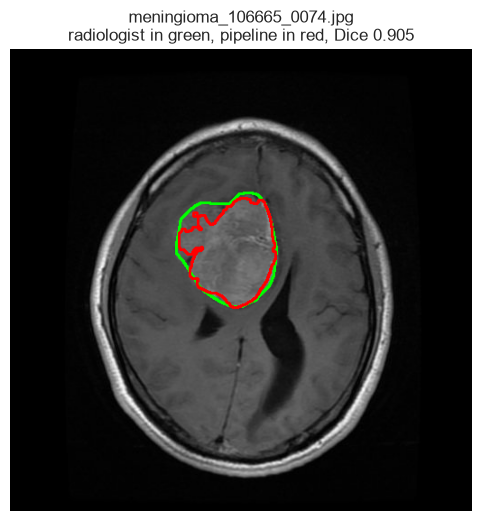

In [8]:
demo_name = "meningioma_106665_0074.jpg"
demo_image, demo_truth = read_slice(demo_name)
demo_predicted = segment_tumour(demo_image)

demo_dice = dice(demo_predicted, demo_truth)
demo_area = demo_predicted.sum() * PIXEL_MM ** 2
truth_area = demo_truth.sum() * PIXEL_MM ** 2

print(f"radiologist: {demo_truth.sum():5d} px = {truth_area:7.0f} mm2")
print(f"pipeline:    {demo_predicted.sum():5d} px = {demo_area:7.0f} mm2")
print(f"Dice overlap: {demo_dice:.3f}")
print(f"the pipeline's area is {1 - demo_area / truth_area:.1%} below the "
      "radiologist's")

outline = cv2.cvtColor(demo_image, cv2.COLOR_GRAY2BGR)
for mask, colour in [(demo_truth, (0, 255, 0)), (demo_predicted, (0, 0, 255))]:
    found, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL,
                                cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(outline, found, -1, colour, 2)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(outline, cv2.COLOR_BGR2RGB))
plt.title(f"{demo_name}\nradiologist in green, pipeline in red, "
          f"Dice {demo_dice:.3f}")
plt.axis("off")
plt.show()

In [9]:
check(
    "demo_dice" in dir() and "demo_area" in dir() and "truth_area" in dir()
    and abs(demo_dice - 0.905) < 0.02
    and abs(demo_area - 2120) < 40
    and abs(truth_area - 2547) < 10,
    "Task 3 complete. Dice 0.905, with the pipeline reporting 2120 mm2 against "
    "the radiologist's 2547 mm2.",
    "Not right yet. Expected demo_dice near 0.905, demo_area near 2120 mm2, "
    "and truth_area near 2547 mm2.",
)

Task 3 complete. Dice 0.905, with the pipeline reporting 2120 mm2 against the radiologist's 2547 mm2.


An overlap of 0.905 is a good result. Note the part that is already less
comfortable: the areas differ by seventeen percent even though the outlines
almost coincide. Dice measures whether you found the right place, and it is not
very sensitive to consistently missing the last ring of pixels around the edge.

Two slices now agree with the radiologist. That is the entire evidence base so
far.

## Task 4: Run It Over Every Meningioma Slice

Two slices are not evidence. Run the pipeline over all 274 meningioma slices
and look at the distribution of the results.

Build a DataFrame called `meningioma_results` with one row per meningioma
slice, holding at least `file`, `patient_id`, `dice`, `pred_mm2`, and
`true_mm2`. Store the mean overlap in `meningioma_dice`.

This takes roughly twenty milliseconds a slice, so the loop finishes in a few
seconds. Plot the distribution of `dice` when you have it.

count    274.000
mean       0.546
std        0.327
min        0.000
25%        0.271
50%        0.665
75%        0.801
max        0.967

mean overlap 0.546
slices above 0.5: 68.2%
slices below 0.1: 21.9%
median reported area as a fraction of the truth: 0.60


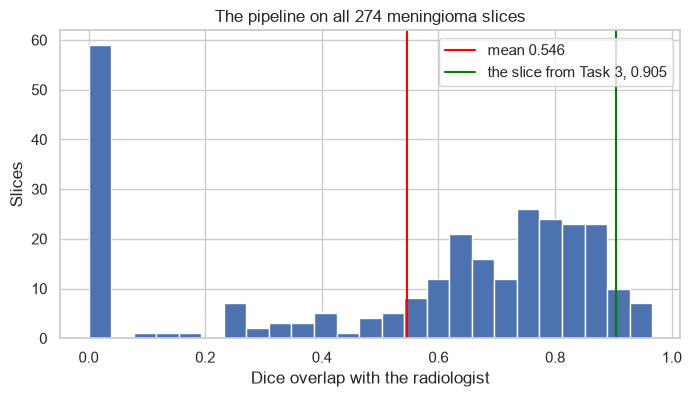

In [10]:
rows = []
for name, patient in slices.loc[
    slices["tumor_type"] == "meningioma", ["file", "patient_id"]
].itertuples(index=False):
    gray, truth = read_slice(name)
    predicted = segment_tumour(gray)
    rows.append({
        "file": name,
        "patient_id": patient,
        "dice": dice(predicted, truth),
        "pred_mm2": predicted.sum() * PIXEL_MM ** 2,
        "true_mm2": truth.sum() * PIXEL_MM ** 2,
    })

meningioma_results = pd.DataFrame(rows)
meningioma_dice = meningioma_results["dice"].mean()

print(meningioma_results["dice"].describe().round(3).to_string())
print(f"\nmean overlap {meningioma_dice:.3f}")
print(f"slices above 0.5: {(meningioma_results['dice'] > 0.5).mean():.1%}")
print(f"slices below 0.1: {(meningioma_results['dice'] < 0.1).mean():.1%}")
ratio = (meningioma_results["pred_mm2"] / meningioma_results["true_mm2"]).median()
print(f"median reported area as a fraction of the truth: {ratio:.2f}")

plt.figure(figsize=(8, 4))
plt.hist(meningioma_results["dice"], bins=25)
plt.axvline(meningioma_dice, color="red",
            label=f"mean {meningioma_dice:.3f}")
plt.axvline(demo_dice, color="green",
            label=f"the slice from Task 3, {demo_dice:.3f}")
plt.xlabel("Dice overlap with the radiologist")
plt.ylabel("Slices")
plt.title("The pipeline on all 274 meningioma slices")
plt.legend()
plt.show()

In [11]:
check(
    "meningioma_results" in dir() and "meningioma_dice" in dir()
    and len(meningioma_results) == 274
    and {"file", "dice", "pred_mm2", "true_mm2"} <= set(meningioma_results.columns)
    and abs(meningioma_dice - 0.546) < 0.02,
    "Task 4 complete. Mean overlap 0.546 across 274 meningioma slices, against "
    "0.905 on the slice you were handed.",
    "Not right yet. Expected `meningioma_results` with 274 rows and a mean "
    "dice near 0.546.",
)

Task 4 complete. Mean overlap 0.546 across 274 meningioma slices, against 0.905 on the slice you were handed.


The mean is 0.546 and the slice you were given scored 0.905. About two thirds
of the slices clear 0.5, and more than a fifth score below 0.1, which means the
pipeline missed the tumour completely on one meningioma slice in five. The
distribution has two humps rather than a spread around the mean, so quoting the
mean alone would describe a typical slice that does not exist.

Also note the median reported area, which is about 0.60 of the truth. Where the
pipeline works at all it systematically finds a smaller tumour than the
radiologist did, because the outer rim of a tumour enhances less brightly than
its core and the brightest cluster stops short of the edge. A bias in one
direction is much worse than noise, because averaging more slices does not
remove it.

## Task 5: Run It Over The Other Two Tumour Types

So far every measurement has come from a meningioma. There are two other
tumour types in the dataset and the pipeline has never been shown one.

Run the same pipeline over all 844 slices. Build a Series called
`dice_by_type`, indexed by tumour type, holding the mean overlap for each, and
keep the full per-slice table in `all_results` because Task 6 needs it.

This is 844 slices rather than 274, so expect it to take about twenty seconds.

             mean  median  above_half  slices
tumor_type                                   
glioma      0.057   0.000       0.045     291
meningioma  0.546   0.665       0.682     274
pituitary   0.049   0.000       0.036     279

mean overlap over all 844 slices: 0.213


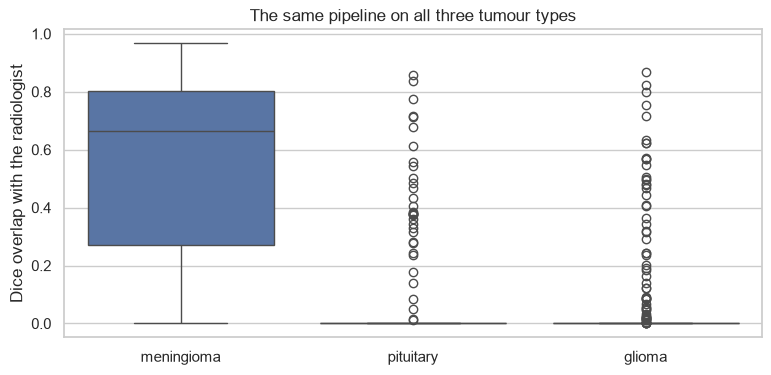

In [12]:
rows = []
for name, patient, tumour in slices[
    ["file", "patient_id", "tumor_type"]
].itertuples(index=False):
    gray, truth = read_slice(name)
    predicted = segment_tumour(gray)
    rows.append({
        "file": name,
        "patient_id": patient,
        "tumor_type": tumour,
        "dice": dice(predicted, truth),
        "pred_mm2": predicted.sum() * PIXEL_MM ** 2,
        "true_mm2": truth.sum() * PIXEL_MM ** 2,
    })

all_results = pd.DataFrame(rows)
dice_by_type = all_results.groupby("tumor_type")["dice"].mean()

summary = all_results.groupby("tumor_type")["dice"].agg(
    mean="mean",
    median="median",
    above_half=lambda column: (column > 0.5).mean(),
    slices="size",
)
print(summary.round(3).to_string())
print(f"\nmean overlap over all 844 slices: {all_results['dice'].mean():.3f}")

plt.figure(figsize=(9, 4))
sns.boxplot(data=all_results, x="tumor_type", y="dice")
plt.ylabel("Dice overlap with the radiologist")
plt.xlabel("")
plt.title("The same pipeline on all three tumour types")
plt.show()

In [13]:
check(
    "all_results" in dir() and "dice_by_type" in dir()
    and len(all_results) == 844
    and abs(dice_by_type["meningioma"] - 0.546) < 0.02
    and dice_by_type["glioma"] < 0.15
    and dice_by_type["pituitary"] < 0.15,
    "Task 5 complete. Meningioma 0.546, glioma 0.057, pituitary 0.049.",
    "Not right yet. Expected `all_results` with 844 rows and `dice_by_type` "
    "holding a mean near 0.546 for meningioma and under 0.15 for both others.",
)

Task 5 complete. Meningioma 0.546, glioma 0.057, pituitary 0.049.


### What The Pipeline Actually Detects

Meningioma 0.546. Glioma 0.057. Pituitary 0.049.

The pipeline does not find tumours. It finds the brightest cluster of pixels
inside the eroded brain, and that happens to be the tumour when the tumour is a
meningioma. Read the assumption back out of the code and it is obvious in
hindsight:

- A meningioma is a well defined mass that takes up contrast strongly, so it is
  the brightest thing left after the skull is eroded away. The method works.
- A glioma infiltrates the tissue around it and enhances patchily or not at
  all, so there is often no bright compact blob to find. The method returns
  whatever else was brightest, which is the wrong place entirely.
- A pituitary tumour sits at the base of the skull among bone, marrow, and fat.
  It is small, and the 35 pixel erosion that removes the skull removes a good
  part of the region it lives in.

Nothing here is a bug. Every line does what it says. The method encodes a claim
about what a tumour looks like, that claim is true for one of the three types
present, and no amount of tuning the kernel sizes will change that.

This is why the slice you are shown in a demonstration matters. The walkthrough
scored 0.96 and this laboratory exercise scores 0.21 over the whole dataset,
using identical code.

## Task 6: Ask How Big The Tumour Is

Now the question the day was set to answer. Patient 106665 has a meningioma,
and the pipeline handles that type as well as it handles anything. Seven of
their slices are consecutive, numbered 0073 to 0079, so they run through the
tumour from one side to the other.

Take those seven slices from `all_results`. Build a DataFrame called `series`
holding, for each, the file name, the radiologist's area, and the pipeline's
area, ordered by file name. Store the ratio of the largest radiologist area to
the smallest in `area_fold`.

Then plot both areas against the slice, and answer the question in your own
head before reading on: what is this patient's tumour area?

                      file  true_mm2  pred_mm2  dice
meningioma_106665_0073.jpg    1805.8    1008.2   0.7
meningioma_106665_0074.jpg    2547.2    2120.3   0.9
meningioma_106665_0075.jpg    2753.9    1608.9   0.7
meningioma_106665_0076.jpg    2508.3    1185.6   0.6
meningioma_106665_0077.jpg    2003.4    1057.6   0.6
meningioma_106665_0078.jpg    1686.5     845.4   0.6
meningioma_106665_0079.jpg     564.7     419.5   0.8

radiologist's smallest area: 565 mm2
radiologist's largest area:  2754 mm2
largest divided by smallest: 4.88


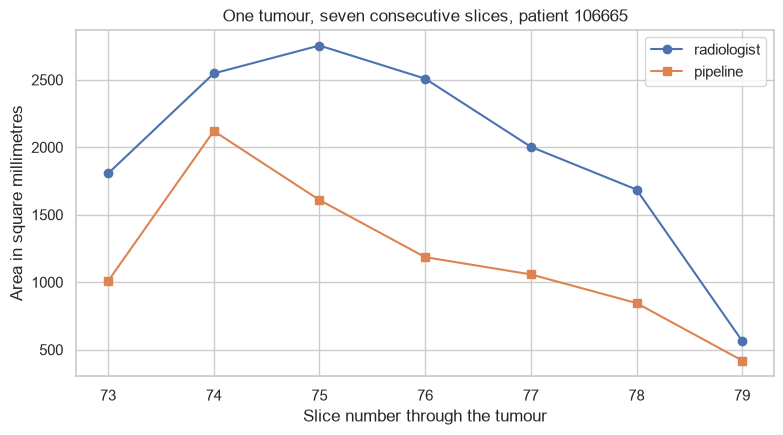

In [14]:
wanted = [f"meningioma_106665_{number:04d}.jpg" for number in range(73, 80)]

series = (
    all_results[all_results["file"].isin(wanted)]
    .sort_values("file")
    .loc[:, ["file", "true_mm2", "pred_mm2", "dice"]]
    .reset_index(drop=True)
)
area_fold = series["true_mm2"].max() / series["true_mm2"].min()

print(series.round(1).to_string(index=False))
print(f"\nradiologist's smallest area: {series['true_mm2'].min():.0f} mm2")
print(f"radiologist's largest area:  {series['true_mm2'].max():.0f} mm2")
print(f"largest divided by smallest: {area_fold:.2f}")

plt.figure(figsize=(9, 4.5))
positions = range(73, 80)
plt.plot(positions, series["true_mm2"], marker="o", label="radiologist")
plt.plot(positions, series["pred_mm2"], marker="s", label="pipeline")
plt.xlabel("Slice number through the tumour")
plt.ylabel("Area in square millimetres")
plt.title("One tumour, seven consecutive slices, patient 106665")
plt.legend()
plt.show()

In [15]:
check(
    "series" in dir() and "area_fold" in dir()
    and len(series) == 7
    and abs(area_fold - 4.88) < 0.1
    and abs(series["true_mm2"].max() - 2754) < 10,
    "Task 6 complete. The radiologist's area runs from 565 to 2754 mm2 across "
    "seven consecutive slices of one tumour, a factor of 4.88.",
    "Not right yet. Expected `series` to have 7 rows and `area_fold` near "
    "4.88.",
)

Task 6 complete. The radiologist's area runs from 565 to 2754 mm2 across seven consecutive slices of one tumour, a factor of 4.88.


### There Is No Such Number As The Tumour's Area

The radiologist's own measurement rises from 565 to 2754 square millimetres and
back down across seven neighbouring slices of one tumour. That is a factor of
4.88, and none of it is error. A tumour is a solid, the slices cut through it at
different depths, and a cut near the middle is larger than a cut near the edge.
The same pattern holds across the dataset, where the median patient's largest
slice is 4.3 times their smallest.

So the question "how large is this tumour" has no answer in square
millimetres. Depending on which slice you happened to measure you could report
565 or 2754 and both would be honest. Reporting the largest is a decision.
Reporting the middle one is a different decision. Neither is the tumour.

The quantity that does exist is a volume, and you can approximate it, because
the archive records that the slices are 6 millimetres thick with a 1 millimetre
gap. Extension 1 asks you to do that.

Notice which mistake was the expensive one. The pipeline's overlap of 0.546 is
a visible, measurable, arguable weakness, and everybody in the room can see it
in the boxplot. The fact that the target quantity was never well defined is
invisible, was never printed by anything, and would have travelled all the way
into a report.

## Task 7: Train A Network To Tell The Three Types Apart

The second question. Given a slice, can a model say whether it shows a glioma,
a meningioma, or a pituitary tumour?

`train_and_score` is written for you. It takes a boolean array with one entry
per row of `slices`, trains on the slices where the array is `True`, and scores
on the rest. `build_model` is a small convolutional network of the kind the
walkthrough described, and `IMAGES` and `LABELS` are already loaded.

Hold out twenty percent of the slices at random, train on the other eighty
percent, and store the accuracy on the held out slices in `slice_accuracy`.

Use `np.random.default_rng(RANDOM_STATE)` so your split is reproducible. On a
GPU this takes a few seconds and on a CPU about a minute.

In [16]:
rng = np.random.default_rng(RANDOM_STATE)

shuffled = rng.permutation(len(slices))
slice_mask = np.zeros(len(slices), bool)
slice_mask[shuffled[:int(0.8 * len(slices))]] = True

slice_train_accuracy, slice_accuracy, _ = train_and_score(slice_mask)

trained on 675 slices, tested on 169
training accuracy 0.938
test accuracy     0.935


In [17]:
check(
    "slice_accuracy" in dir() and slice_accuracy > 0.85,
    "Task 7 complete. The network reaches an accuracy well above the 0.33 a "
    "coin would give on three classes. Now go back and read your answer to "
    "Task 1 again.",
    "Not right yet. Expected `slice_accuracy` above 0.85 from an 80 to 20 "
    "split chosen at random over the slices.",
)

Task 7 complete. The network reaches an accuracy well above the 0.33 a coin would give on three classes. Now go back and read your answer to Task 1 again.


### Go Back And Look At Task 1

You have a number, and it is a good one. Around nine slices in ten are given
the right tumour type by a network with about twenty-six thousand parameters,
trained in under a minute, on 675 images. If you were writing this up, this is
the figure that would go in the abstract.

Now recall what you were told to set aside. The median patient in this dataset
contributed 14 slices.

Your split shuffled slices. It did not shuffle patients. So for almost every
slice in your held out set, the same patient's other thirteen slices were in
the training set, showing the same brain, the same tumour, and the same
diagnosis from a position a few millimetres away.

## Task 8: Measure It Again Without The Leak

Split by patient instead of by slice. Every slice belonging to a patient has to
land on the same side of the split, so that no patient the network trained on
appears in the held out set.

Hold out roughly twenty percent of the patients within each tumour type, which
keeps the classes balanced, and train on the rest. Store the accuracy on the
held out slices in `patient_accuracy`, and the fraction of held out slices
whose patient also appears in training in `leak_fraction`, which should now be
zero.

Also compute `leak_fraction_before`, the same fraction for the split you used
in Task 7, so the two are side by side.

In [18]:
patients = slices["patient_id"].to_numpy()

rng = np.random.default_rng(RANDOM_STATE)
patient_mask = np.zeros(len(slices), bool)
for tumour in TUMOUR_TYPES:
    # Choosing patients rather than slices is the whole of the fix.
    pool = sorted(slices.loc[slices["tumor_type"] == tumour,
                             "patient_id"].unique())
    keep = set(rng.permutation(pool)[:18].tolist())
    patient_mask |= (np.isin(patients, list(keep))
                     & (slices["tumor_type"] == tumour).to_numpy())


def leaked(mask):
    """Fraction of held out slices whose patient is also in the training set."""
    return float(np.isin(patients[~mask], patients[mask]).mean())


leak_fraction_before = leaked(slice_mask)
leak_fraction = leaked(patient_mask)

print(f"held out patients: {slices.loc[~patient_mask, 'patient_id'].nunique()}")
print(f"held out slices:   {(~patient_mask).sum()}")
print()
patient_train_accuracy, patient_accuracy, patient_pred = \
    train_and_score(patient_mask)

print()
print(f"Task 7, split by slice:   accuracy {slice_accuracy:.3f}, "
      f"{leak_fraction_before:.1%} of held out slices share a patient with "
      "training")
print(f"Task 8, split by patient: accuracy {patient_accuracy:.3f}, "
      f"{leak_fraction:.1%} of held out slices share a patient with training")
print(f"the honest figure is {patient_accuracy - slice_accuracy:+.3f} against "
      "the one you would have reported")

held out patients: 12
held out slices:   153



trained on 691 slices, tested on 153
training accuracy 0.975
test accuracy     0.712

Task 7, split by slice:   accuracy 0.935, 100.0% of held out slices share a patient with training
Task 8, split by patient: accuracy 0.712, 0.0% of held out slices share a patient with training
the honest figure is -0.222 against the one you would have reported


In [19]:
check(
    "patient_accuracy" in dir() and "leak_fraction" in dir()
    and "leak_fraction_before" in dir()
    and leak_fraction == 0.0
    and leak_fraction_before > 0.95
    and patient_accuracy < slice_accuracy - 0.05,
    "Task 8 complete. Every held out slice in Task 7 shared a patient with the "
    "training set, and removing that overlap costs a large part of the "
    "accuracy you were about to report.",
    "Not right yet. Expected leak_fraction to be exactly 0.0, "
    "leak_fraction_before above 0.95, and patient_accuracy at least 0.05 below "
    "slice_accuracy.",
)

Task 8 complete. Every held out slice in Task 7 shared a patient with the training set, and removing that overlap costs a large part of the accuracy you were about to report.


### What Just Happened

Nothing about the model changed. The same architecture, the same seed, the same
number of epochs, and very nearly the same number of training slices. The only
difference is which slices were held out, and the accuracy fell by about twenty
points.

Two measurements sit behind that figure. Averaged over four random splits on the
processor these materials were prepared on, the slice split scored 0.911 and the
patient split 0.748, a gap of sixteen points. A single run on a graphics
processor gave 0.935 and 0.712, a gap of twenty-two. Your own numbers will land
somewhere nearby and will match neither pair, because the result depends on
which patients fall in the held out set and on the hardware the network trained
on.

What does not move is the direction and the rough size. Across those four
splits the worst slice split still beat the best patient split, so the two are
not overlapping distributions that happened to fall the wrong way round.

Here is why the first number was not measuring what it appeared to measure. To
score a held out slice correctly, the network had two routes available. It could
learn what a glioma looks like, which is the thing you wanted. Or it could
recognise this particular brain, which it had seen thirteen times already, and
recall the answer. The second route is easier, and gradient descent takes the
easier route.

The second number answers the question a clinician would ask, which is whether
the model works on a patient it has never seen. That is the only question worth
asking, and the only split that answers it is one that keeps a patient whole.

The general shape is worth carrying beyond this dataset. Yesterday a broken
sensor was hidden by averaging across sensors. Today a broken evaluation was
hidden by splitting across slices. Both are the same error, which is treating a
group of related measurements as if they were independent observations. Ask what
the unit of observation really is, and split on that, whether it is a patient, a
sensor, a hospital, a subject, or a day.

And note that nothing in Task 7 could have caught it. The accuracy was high and
the training was uneventful, and had you gone on to plot a loss curve or a
confusion matrix they would have looked healthy too, because the network really
was doing well at the task as you had posed it. The fault was in the question,
and no diagnostic computed from the answer can find a fault in the question.

## Extensions

Each of these is worked through below.

1. Approximate patient 106665's tumour volume. The archive records a slice
   thickness of 6 millimetres and a gap of 1 millimetre, so each slice stands
   for 7 millimetres of depth. Multiply each area by that and add them up, then
   say what the answer would have been had you used the largest slice and
   multiplied by seven slices instead.
2. The pipeline reports about 0.60 of the true area on meningioma. Find out
   whether raising the number of clusters from three to four recovers the
   missing rim, and whether it costs anything on the slices that already work.
3. Exclude patient 108931 from Task 5 and see whether any of the three figures
   moves. Then work out how large the error on that patient's areas would have
   to be before it did move, which tells you whether Task 2 mattered in
   practice or only in principle.
4. Run Task 8 again with a different seed, five times, and report the mean and
   the spread of `patient_accuracy`. Compare that spread against the gap you
   measured, and decide whether four splits were enough evidence.
5. The network sees images resized to 96 by 96. Given what Section 4 of the
   walkthrough showed about resizing, decide whether that resize threatens the
   classification the way it threatened the measurement, and say why.
6. Build a classifier that never looks at a pixel, using only the width and the
   height of each image, and score it with a patient level split. It should
   land at the majority class rate of about 0.35, which is to say it learns
   nothing, because every slice here came from one archive and the dimensions
   carry no signal. Then add the size of each file in bytes as a third feature
   and score it again. It rises to about 0.53, well clear of chance, and the
   interesting question is whether that counts as a leak. Argue it both ways
   before deciding, and note that a dataset assembled from several archives can
   fail this test on the dimensions alone.

### Extension 1: The Volume The Slices Do Support

Task 6 left the question without an answer in square millimetres. The archive
supplies the dimension the slices are missing, which is 6 millimetres of tissue
followed by a 1 millimetre gap, so each slice stands for 7 millimetres of
depth. Multiply each area by that depth and add the slabs up.

Then do it the way a hurried report would, by taking the largest slice and
multiplying it by the number of slices, and compare the two.

                      file  true_mm2  true_cm3  pred_cm3
meningioma_106665_0073.jpg   1805.79     12.64      7.06
meningioma_106665_0074.jpg   2547.22     17.83     14.84
meningioma_106665_0075.jpg   2753.95     19.28     11.26
meningioma_106665_0076.jpg   2508.32     17.56      8.30
meningioma_106665_0077.jpg   2003.39     14.02      7.40
meningioma_106665_0078.jpg   1686.46     11.81      5.92
meningioma_106665_0079.jpg    564.72      3.95      2.94

adding the seven slabs:        97.1 cm3
largest slice times seven:    134.9 cm3, +39%
smallest slice times seven:    27.7 cm3, -71%
the pipeline's own slabs:      57.7 cm3, 0.59 of the radiologist's volume


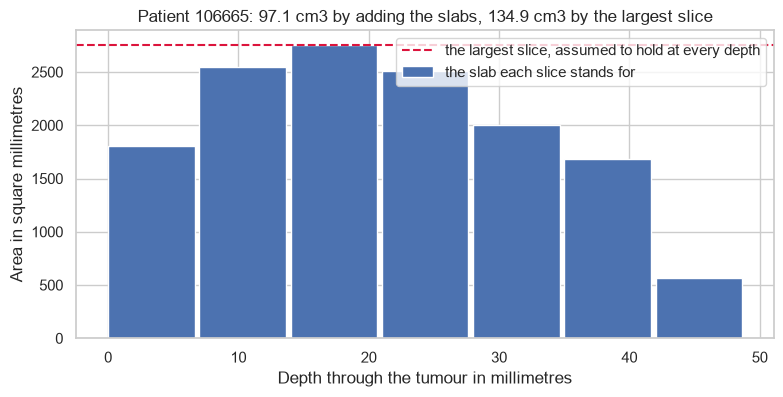

In [20]:
SLICE_DEPTH_MM = 6 + 1  # The tissue in a slice, and the gap before the next.

slabs = series.assign(
    true_cm3=series["true_mm2"] * SLICE_DEPTH_MM / 1000,
    pred_cm3=series["pred_mm2"] * SLICE_DEPTH_MM / 1000,
)
summed_cm3 = slabs["true_cm3"].sum()
largest_cm3 = series["true_mm2"].max() * SLICE_DEPTH_MM * len(series) / 1000
smallest_cm3 = series["true_mm2"].min() * SLICE_DEPTH_MM * len(series) / 1000
pipeline_cm3 = slabs["pred_cm3"].sum()

print(slabs[["file", "true_mm2", "true_cm3", "pred_cm3"]].round(2).to_string(
    index=False))
print(f"\nadding the seven slabs:      {summed_cm3:6.1f} cm3")
print(f"largest slice times seven:   {largest_cm3:6.1f} cm3, "
      f"{largest_cm3 / summed_cm3 - 1:+.0%}")
print(f"smallest slice times seven:  {smallest_cm3:6.1f} cm3, "
      f"{smallest_cm3 / summed_cm3 - 1:+.0%}")
print(f"the pipeline's own slabs:    {pipeline_cm3:6.1f} cm3, "
      f"{pipeline_cm3 / summed_cm3:.2f} of the radiologist's volume")

depth = np.arange(len(series)) * SLICE_DEPTH_MM

plt.figure(figsize=(9, 4))
plt.bar(depth, series["true_mm2"], width=SLICE_DEPTH_MM * 0.95, align="edge",
        label="the slab each slice stands for")
plt.axhline(series["true_mm2"].max(), color="crimson", linestyle="--",
            label="the largest slice, assumed to hold at every depth")
plt.xlabel("Depth through the tumour in millimetres")
plt.ylabel("Area in square millimetres")
plt.title(f"Patient 106665: {summed_cm3:.1f} cm3 by adding the slabs, "
          f"{largest_cm3:.1f} cm3 by the largest slice")
plt.legend()
plt.show()

Adding the slabs gives 97.1 cubic centimetres. Taking the largest slice and
multiplying by seven gives 134.9, which is 39 percent more, and taking the
smallest gives 27.7, which is 71 percent less. All three are arithmetic on the
radiologist's own outlines, and the spread between them is the same fact Task 6
found, now carried into a quantity that does have an answer.

Two things qualify the 97.1. It assumes each slab holds its slice's area
throughout its depth, which squares off a shape that is round, and it assumes
the seven slices cover the tumour. The first slice already measures 1806 square
millimetres, two thirds of the largest, so the series does not begin at the
tumour's edge and 97.1 is a floor rather than an estimate with room either
side. The archive holds no slice of this patient numbered below 0073, so
nothing extends the series at that end.

The pipeline's own volume is 57.7 cubic centimetres, which is 0.59 of the
radiologist's. That is the area bias from Task 4 arriving unchanged. Adding
seven slabs averages nothing away, because every one of them is short by the
same rim.

What the extension is really about is that the question became answerable once
it was asked about the right quantity. Nothing was added to the data. The
volume was available all along, and asking for the area is what made it
impossible to answer.

### Extension 2: Whether A Fourth Cluster Recovers The Rim

The pipeline reports about 0.60 of the true area on meningioma because the
brightest cluster stops short of the tumour's edge. The obvious repair is to
give k-means one more cluster, so that the rim has a group of its own to fall
into. Run the whole dataset again with `clusters=4` and compare it against
`all_results`, both where the method already works and where it does not.

            mean dice, 3  mean dice, 4  median area ratio, 3  median area ratio, 4
tumor_type                                                                        
glioma             0.057         0.036                 0.192                 0.099
meningioma         0.546         0.448                 0.598                 0.444
pituitary          0.049         0.043                 0.476                 0.344

of the 187 meningioma slices that already cleared 0.5, 1 improved and 186 got worse
their mean overlap went from 0.751 to 0.591


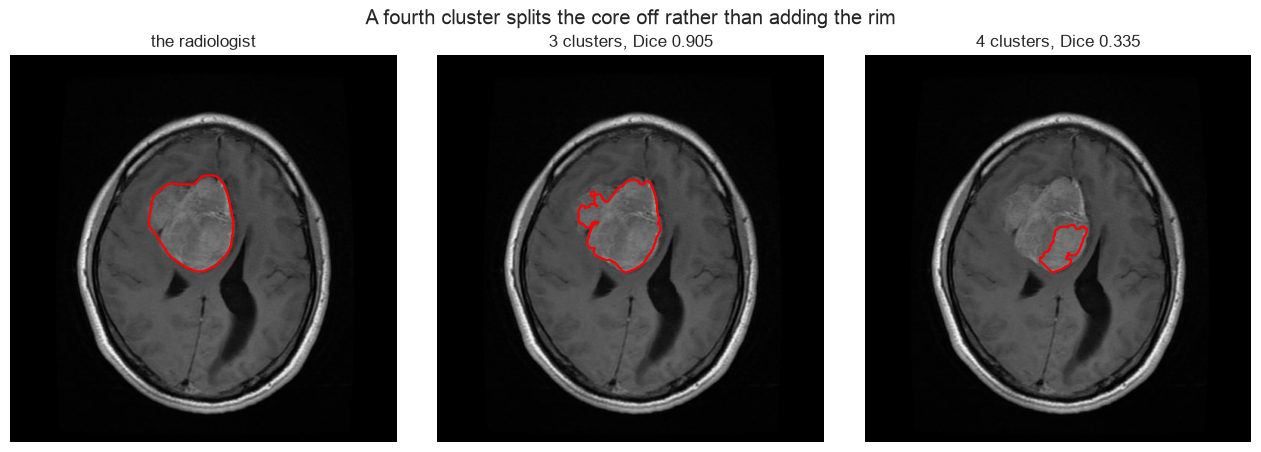

In [21]:
rows = []
for name, patient, tumour in slices[
    ["file", "patient_id", "tumor_type"]
].itertuples(index=False):
    gray, truth = read_slice(name)
    predicted = segment_tumour(gray, clusters=4)
    rows.append({
        "file": name,
        "patient_id": patient,
        "tumor_type": tumour,
        "dice": dice(predicted, truth),
        "pred_mm2": predicted.sum() * PIXEL_MM ** 2,
        "true_mm2": truth.sum() * PIXEL_MM ** 2,
    })

four_cluster = pd.DataFrame(rows)

both = all_results.merge(four_cluster, on=["file", "patient_id", "tumor_type"],
                         suffixes=("_3", "_4"))
both["ratio_3"] = both["pred_mm2_3"] / both["true_mm2_3"]
both["ratio_4"] = both["pred_mm2_4"] / both["true_mm2_4"]

grouped = both.groupby("tumor_type")
print(pd.DataFrame({
    "mean dice, 3": grouped["dice_3"].mean(),
    "mean dice, 4": grouped["dice_4"].mean(),
    "median area ratio, 3": grouped["ratio_3"].median(),
    "median area ratio, 4": grouped["ratio_4"].median(),
}).round(3).to_string())

worked = both[(both["tumor_type"] == "meningioma") & (both["dice_3"] > 0.5)]
better = int((worked["dice_4"] > worked["dice_3"]).sum())
print(f"\nof the {len(worked)} meningioma slices that already cleared 0.5, "
      f"{better} improved and {len(worked) - better} got worse")
print(f"their mean overlap went from {worked['dice_3'].mean():.3f} to "
      f"{worked['dice_4'].mean():.3f}")

demo_four = segment_tumour(demo_image, clusters=4)
panels = [
    (demo_truth, "the radiologist"),
    (segment_tumour(demo_image), f"3 clusters, Dice {demo_dice:.3f}"),
    (demo_four, f"4 clusters, Dice {dice(demo_four, demo_truth):.3f}"),
]

figure, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for axis, (mask, title) in zip(axes, panels):
    axis.imshow(demo_image, cmap="gray")
    axis.contour(mask, levels=[0.5], colors="red", linewidths=1.5)
    axis.set_title(title)
    axis.axis("off")
figure.suptitle("A fourth cluster splits the core off rather than adding "
                "the rim")
plt.tight_layout()
plt.show()

It makes everything worse. Meningioma falls from 0.546 to 0.448, glioma from
0.057 to 0.036, and pituitary from 0.049 to 0.043. The median reported area on
meningioma, which was the thing being repaired, drops from 0.60 of the truth to
0.44. Of the 187 meningioma slices that already cleared an overlap of 0.5,
exactly one improved, and their mean overlap fell from 0.751 to 0.591.

The picture says why. K-means partitions the whole range of brightnesses rather
than growing a region outward, so a fourth cluster subdivides the bright end
into a very bright core and a merely bright shell. The pipeline then keeps
whichever single cluster is brightest, which is now the core alone. The rim was
never going to be annexed by a step that keeps exactly one cluster, and asking
for more groups moves the boundary inward every time.

A bias toward too small is not repaired by a finer partition. It would need
either a step that grows the region back out from the core, such as a dilation
or a region growing pass keyed to the edge, or a criterion that is not
brightness at all. That is the useful shape of the result: the parameter was
tuned, the number moved, and it moved in the wrong direction, because the
parameter was never what was wrong.

### Extension 3: What Excluding Patient 108931 Costs

Task 2 found 14 slices whose pixel spacing the archive never recorded, and said
the honest treatment is to exclude that patient from any figure quoted in
millimetres. Recompute Task 5 without them and see what moves. Then bound how
much that patient could have mattered at all, by asking what the three figures
would read if the pipeline had been perfect on those 14 slices instead.

In [22]:
kept = all_results[all_results["patient_id"] != "108931"]

side_by_side = pd.DataFrame({
    "all 844 slices": dice_by_type,
    "without 108931": kept.groupby("tumor_type")["dice"].mean(),
})
side_by_side["difference"] = (side_by_side["without 108931"]
                              - side_by_side["all 844 slices"])
print(side_by_side.round(4).to_string())
print(f"\nover every slice: {all_results['dice'].mean():.4f} with the patient, "
      f"{kept['dice'].mean():.4f} without")

pituitary = all_results[all_results["tumor_type"] == "pituitary"]
excluded = pituitary[pituitary["patient_id"] == "108931"]
remaining = pituitary[pituitary["patient_id"] != "108931"]

print(f"\npatient 108931 scored a mean overlap of {excluded['dice'].mean():.4f} "
      f"over {len(excluded)} slices, against {remaining['dice'].mean():.4f} "
      f"over the other {len(remaining)}")
for hypothetical in (0.0, 1.0):
    moved = (remaining["dice"].sum()
             + len(excluded) * hypothetical) / len(pituitary)
    print(f"  had all {len(excluded)} scored {hypothetical:.1f}, the pituitary "
          f"mean would read {moved:.4f}")

# Dice is a ratio of pixel counts, so PIXEL_MM cancels out of it and the
# unrecorded spacing cannot reach the figures above. The areas are where it
# lands, so compare them under both readings of the spacing.
doubled = (remaining["true_mm2"].sum()
           + excluded["true_mm2"].sum() * 4) / len(pituitary)
print(f"\nmean pituitary area at 0.49 mm throughout:       "
      f"{pituitary['true_mm2'].mean():.0f} mm2")
print(f"mean pituitary area at 0.98 mm for 108931 alone: {doubled:.0f} mm2")
print(f"that patient's own mean area: {excluded['true_mm2'].mean():.0f} mm2 "
      f"against {excluded['true_mm2'].mean() * 4:.0f} mm2")

            all 844 slices  without 108931  difference
tumor_type                                            
glioma              0.0573          0.0573      0.0000
meningioma          0.5464          0.5464      0.0000
pituitary           0.0492          0.0518      0.0026

over every slice: 0.2134 with the patient, 0.2170 without

patient 108931 scored a mean overlap of 0.0000 over 14 slices, against 0.0518 over the other 265
  had all 14 scored 0.0, the pituitary mean would read 0.0492
  had all 14 scored 1.0, the pituitary mean would read 0.0994

mean pituitary area at 0.49 mm throughout:       442 mm2
mean pituitary area at 0.98 mm for 108931 alone: 464 mm2
that patient's own mean area: 149 mm2 against 596 mm2


One figure moves and it moves by 0.0026. Pituitary goes from 0.0492 to 0.0518
and the mean over every slice from 0.2134 to 0.2170, while glioma and
meningioma do not move at all, because neither contains a slice of this
patient.

Now the second half of the question, which is how large the error on that
patient's areas would have to be before it moved those figures. The answer is
that no error of any size would move them. Dice is twice the intersection
divided by the sum of the two pixel counts, and `PIXEL_MM` appears nowhere in
it, so whatever the true spacing was, Task 5 would print exactly the same three
numbers. The exclusion changes them only by dropping 14 rows out of an average,
which is a different operation from correcting anything.

The patient's leverage is small in the other direction too. Those 14 slices
score 0.0000, every one of them, and even if the pipeline had been perfect on
all fourteen the pituitary mean would read 0.0994. That is still an order below
meningioma's 0.546, so no treatment of this patient touches the conclusion of
Task 5.

Where the spacing does land is the areas, and there it is a factor of four. The
patient's mean tumour area reads 149 square millimetres at 0.49 millimetres and
596 at 0.98, and the pituitary mean over all 279 slices moves from 442 to 464
depending which you believe. That is five percent, on a figure nobody could
defend either way.

So Task 2 mattered in principle and, on this dataset, barely in practice. That
is the honest answer and it is not an argument against the check. The check
costs one line, the consequence is set by how many slices were affected rather
than by anything you can see, and the only way to find out which sort of
dataset you have is to run it.

### Extension 4: How Much Of The Gap Is The Split

Task 8 rests on one patient level split, which holds out twelve people out of
66. Twelve is a small number to draw a conclusion from, and the objection
deserves a measurement rather than a reassurance.

Repeat both splits at five seeds. Only the split changes, because
`train_and_score` seeds the weights and the batch order from `RANDOM_STATE`
whatever it is given, so the spread below is the spread due to which patients
were held out and nothing else.

seed    42: by slice 0.935, by patient 0.712, gap +0.222


seed     7: by slice 0.917, by patient 0.772, gap +0.145


seed    13: by slice 0.899, by patient 0.858, gap +0.041


seed  2024: by slice 0.882, by patient 0.697, gap +0.184


seed    99: by slice 0.899, by patient 0.800, gap +0.099

      by_slice  by_patient    gap
mean     0.907       0.768  0.139
std      0.020       0.066  0.071
min      0.882       0.697  0.041
max      0.935       0.858  0.222

worst slice level split 0.882, best patient level split 0.858


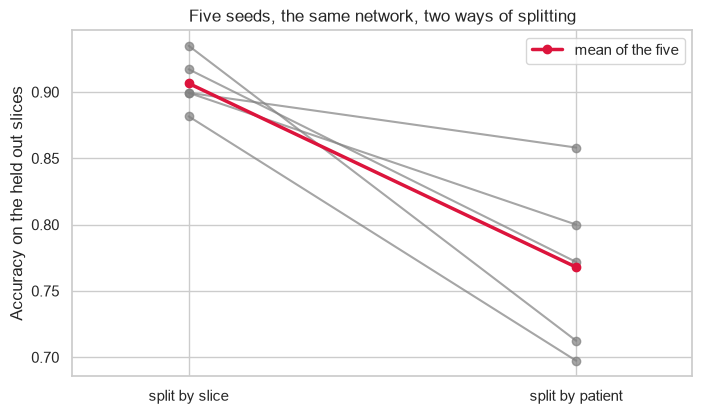

In [23]:
def slice_split(seed):
    """The Task 7 split, with the seed exposed."""
    generator = np.random.default_rng(seed)
    shuffled = generator.permutation(len(slices))
    mask = np.zeros(len(slices), bool)
    mask[shuffled[:int(0.8 * len(slices))]] = True
    return mask


def patient_split(seed):
    """The Task 8 split, with the seed exposed."""
    generator = np.random.default_rng(seed)
    mask = np.zeros(len(slices), bool)
    for tumour in TUMOUR_TYPES:
        pool = sorted(slices.loc[slices["tumor_type"] == tumour,
                                 "patient_id"].unique())
        keep = set(generator.permutation(pool)[:18].tolist())
        mask |= (np.isin(patients, list(keep))
                 & (slices["tumor_type"] == tumour).to_numpy())
    return mask


# At the seed the tasks used, both functions have to reproduce the tasks
# exactly, or the spread below would be measuring the rewrite instead.
assert (slice_split(RANDOM_STATE) == slice_mask).all()
assert (patient_split(RANDOM_STATE) == patient_mask).all()

SPLIT_SEEDS = [42, 7, 13, 2024, 99]

rows = []
for seed in SPLIT_SEEDS:
    by_slice = slice_split(seed)
    by_patient = patient_split(seed)
    _, slice_score, _ = train_and_score(by_slice, verbose=False)
    _, patient_score, _ = train_and_score(by_patient, verbose=False)
    rows.append({
        "seed": seed,
        "held_out_patients": slices.loc[~by_patient, "patient_id"].nunique(),
        "by_slice": slice_score,
        "by_patient": patient_score,
        "gap": slice_score - patient_score,
    })
    print(f"seed {seed:>5d}: by slice {slice_score:.3f}, by patient "
          f"{patient_score:.3f}, gap {slice_score - patient_score:+.3f}")

repeats = pd.DataFrame(rows)
print()
print(repeats[["by_slice", "by_patient", "gap"]]
      .agg(["mean", "std", "min", "max"]).round(3).to_string())
print(f"\nworst slice level split {repeats['by_slice'].min():.3f}, "
      f"best patient level split {repeats['by_patient'].max():.3f}")

plt.figure(figsize=(8, 4.5))
for row in repeats.itertuples(index=False):
    plt.plot([0, 1], [row.by_slice, row.by_patient], marker="o", color="grey",
             alpha=0.7)
plt.plot([0, 1], [repeats["by_slice"].mean(), repeats["by_patient"].mean()],
         marker="o", color="crimson", linewidth=2.5, label="mean of the five")
plt.xticks([0, 1], ["split by slice", "split by patient"])
plt.xlim(-0.3, 1.3)
plt.ylabel("Accuracy on the held out slices")
plt.title("Five seeds, the same network, two ways of splitting")
plt.legend()
plt.show()

The direction never reverses and the size is not well determined. Across the
five seeds the slice level split scored 0.935, 0.917, 0.899, 0.882, and 0.899,
a mean of 0.907 with a standard deviation of 0.020. The patient level split
scored 0.712, 0.772, 0.858, 0.697, and 0.800, a mean of 0.768 with a standard
deviation of 0.066. The gap ran from 0.041 to 0.222.

So the spread on the honest figure is three times the spread on the leaky one,
and the arithmetic behind that is worth stating. A slice level split holds out
169 images drawn independently, whereas a patient level split holds out twelve
people who bring their slices with them, so one unusual patient moves the
figure by as much as fourteen images can. Fewer independent things were held
out, and the number is correspondingly less stable.

Five splits are ample evidence for the direction and thin evidence for the
size. The worst slice level split, 0.882, still beat the best patient level
split, 0.858, so these are not two overlapping distributions that happened to
fall the wrong way round in Task 8. But quoting "the accuracy falls by twenty
points" from a single split overstates what one split can support, and "the
accuracy falls, by something between four and twenty-two points across five
seeds" is what the evidence actually says. The four splits behind the figures
quoted after Task 8 earn exactly the same verdict.

Note also which way the uncertainty runs. It does not rescue the number. Even
the most fortunate of the five patient level splits lands below every slice
level split, so a wide interval here is a reason to report an interval rather
than a reason to prefer the higher figure.

If the size mattered to a decision, the answer is not more epochs. It is more
held out patients, which means cross validation over patients rather than one
split, at the cost of one training per fold. These figures were measured on one
machine's graphics processor, and both columns move with the hardware and
between runs on the same hardware, while the shape of the result does not.

### Extension 5: Whether The Resize To 96 By 96 Threatens The Classification

Section 4 of the walkthrough broke a measurement twice with a resize, and the
two breakages were separate. The first was arithmetic: a pixel count converted
into millimetres with a spacing recorded for a different pixel size. The second
was a parameter: an erosion of 35 pixels standing for a different distance once
the image was smaller.

Tasks 7 and 8 resize every slice to 96 by 96. Take the two failures one at a
time, then measure.

In [24]:
def train_returning_model(images, train_mask, epochs=EPOCHS):
    """Train exactly as `train_and_score` does and hand the model back.

    Scoring one set of weights on images prepared at a second size is the
    experiment below, and `train_and_score` keeps its model to itself.
    """
    torch.manual_seed(RANDOM_STATE)
    train_x = torch.tensor(images[train_mask]).unsqueeze(1)
    train_y = torch.tensor(LABELS[train_mask])

    model = build_model().to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_function = nn.CrossEntropyLoss()
    generator = torch.Generator().manual_seed(RANDOM_STATE)

    for epoch in range(epochs):
        model.train()
        order = torch.randperm(len(train_x), generator=generator)
        for start in range(0, len(order), 32):
            batch = order[start:start + 32]
            optimiser.zero_grad()
            loss = loss_function(model(train_x[batch].to(DEVICE)),
                                 train_y[batch].to(DEVICE))
            loss.backward()
            optimiser.step()

    model.eval()
    return model


def score_model(model, images, test_mask):
    """Accuracy of one model on the slices the mask selects."""
    with torch.no_grad():
        predicted = model(
            torch.tensor(images[test_mask]).unsqueeze(1).to(DEVICE)
        ).argmax(1).cpu().numpy()
    return float((predicted == LABELS[test_mask]).mean())


# Every size is a multiple of 32, so that three poolings leave a side the
# adaptive pool's output of 4 divides evenly. Some devices refuse it otherwise.
SIZES = [64, 96, 128, 192]
bank = {size: IMAGES if size == IMAGE_SIZE else load_all_images(size)[0]
        for size in SIZES}

print(f"a 3 by 3 kernel spans {3 * 512 * PIXEL_MM / IMAGE_SIZE:.1f} mm of head "
      f"at {IMAGE_SIZE} and {3 * PIXEL_MM:.1f} mm at 512")

print("\ntrained and scored at the same size, on the Task 8 patient split:")
matched = {}
for size in SIZES:
    matched[size] = score_model(train_returning_model(bank[size], patient_mask),
                                bank[size], ~patient_mask)
    print(f"  {size:3d} by {size:<3d} {matched[size]:.3f}")

print("\ntrained at 96 by 96, scored on the same patients at other sizes:")
model_96 = train_returning_model(IMAGES, patient_mask)
for size in SIZES:
    mismatched = score_model(model_96, bank[size], ~patient_mask)
    print(f"  {size:3d} by {size:<3d} {mismatched:.3f}")

a 3 by 3 kernel spans 7.8 mm of head at 96 and 1.5 mm at 512

trained and scored at the same size, on the Task 8 patient split:


   64 by 64  0.765


   96 by 96  0.712


  128 by 128 0.778


  192 by 192 0.784

trained at 96 by 96, scored on the same patients at other sizes:


   64 by 64  0.673
   96 by 96  0.712
  128 by 128 0.712
  192 by 192 0.634


The first failure cannot occur here. Nothing in Tasks 7 and 8 is expressed in
millimetres. The network consumes pixels and emits a class, a class has no
units, and there is no conversion to invalidate. That is the whole of the
answer to the first half.

The second failure has a real analogue. The 3 by 3 kernels and the poolings are
measured in pixels, so a kernel spans about 7.8 millimetres of head at 96 by 96
and about 1.5 at 512. The network is looking at a coarser structure than its
architecture suggests. What saves it is that every image passes through the
same resize at training and at scoring, so the weights are fitted for the width
they will meet. The measurement had no such protection, because there the
spacing was fixed in the archive while the pixels moved underneath it.
Consistency is what the network needs, and correctness is what the measurement
needed.

The figures bear that out and they also show how little the size buys. Trained
and scored at the same size the accuracy reads 0.765, 0.712, 0.778, and 0.784
at 64, 96, 128, and 192. Every one of them sits inside the 0.697 to 0.858 range
that Extension 4 measured for the choice of split alone, so four times the
pixels is not separable from the noise of which twelve patients were held out.

The mismatch check runs the way the argument predicts and is equally not
significant. The model trained at 96 scores 0.712 at 96 and at 128, 0.673 at
64, and 0.634 at 192. The direction is right and the size is inside the split
noise, so this is suggestive rather than demonstrated, and showing it properly
would need the cross validation Extension 4 pointed at.

The distinction to carry away is between a transformation that changes what a
number means and one that only discards information. The resize to 96 by 96
throws away detail, which caps how well any model can do, and it biases
nothing.

### Extension 6: A Classifier That Never Looks At A Pixel

A cheap check on any image dataset is to model it from the properties of the
files rather than from their contents. Anything predictable from the width, the
height, or the size on disk is predictable without learning what a tumour looks
like.

Score it with the Task 8 patient level split, so that the comparison is against
0.712 rather than against the figure Task 7 produced.

share of each class among the held out slices:
glioma        0.353
pituitary     0.327
meningioma    0.320

['width', 'height']: accuracy 0.353
  it predicted 153 glioma, 0 meningioma, 0 pituitary



['width', 'height', 'bytes']: accuracy 0.523
  it predicted 51 glioma, 67 meningioma, 35 pituitary



bytes against detail, over all 844 slices:      0.269
bytes against detail, over the 512 by 512 ones: 0.959

              bytes  detail
tumor_type                 
glioma      23169.0    3.32
meningioma  25136.5    3.43
pituitary   33975.0    5.07

           bytes          detail       
           count   median  count median
resolution                             
256 by 256    14  15296.0     14  17.41
512 by 512   830  26548.0    830   3.81


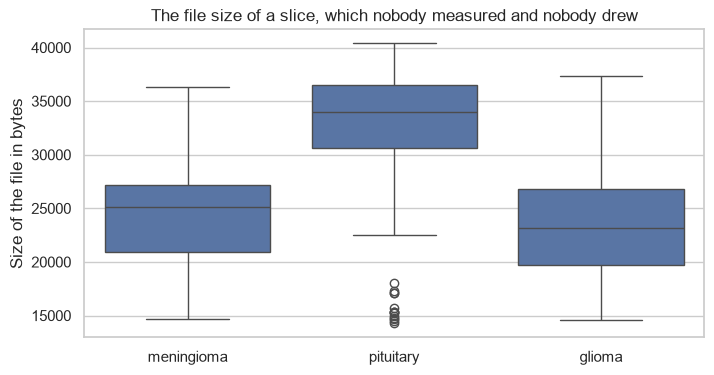

In [25]:
from sklearn.ensemble import RandomForestClassifier

file_bytes = [(SLICE_DIR / name).stat().st_size for name in slices["file"]]
metadata = pd.DataFrame({
    "width": measured["width"],
    "height": measured["height"],
    "bytes": file_bytes,
})
held_out_labels = LABELS[~patient_mask]

print("share of each class among the held out slices:")
print(pd.Series(held_out_labels).value_counts(normalize=True)
      .rename(index=dict(enumerate(TUMOUR_TYPES))).round(3).to_string())

for columns in (["width", "height"], ["width", "height", "bytes"]):
    forest = RandomForestClassifier(n_estimators=200,
                                    random_state=RANDOM_STATE)
    forest.fit(metadata.loc[patient_mask, columns], LABELS[patient_mask])
    predicted = forest.predict(metadata.loc[~patient_mask, columns])
    counted = np.bincount(predicted, minlength=3)
    print(f"\n{columns}: accuracy {(predicted == held_out_labels).mean():.3f}")
    print("  it predicted " + ", ".join(
        f"{count} {name}" for name, count in zip(TUMOUR_TYPES, counted)))

# A byte count is only a leak if it is a property of how the file reached the
# folder rather than of the picture inside it, so measure how much of it is
# picture. The Laplacian's mean magnitude is a plain measure of fine detail,
# which is what a JPEG spends its bytes on.
detail = np.array([
    np.abs(cv2.Laplacian(
        cv2.imread(str(SLICE_DIR / name), cv2.IMREAD_GRAYSCALE).astype(
            np.float32), cv2.CV_32F)).mean()
    for name in slices["file"]
])
full_size = (metadata["width"] * metadata["height"] == 512 * 512).to_numpy()

print(f"\nbytes against detail, over all 844 slices:      "
      f"{np.corrcoef(metadata['bytes'], detail)[0, 1]:.3f}")
print(f"bytes against detail, over the 512 by 512 ones: "
      f"{np.corrcoef(metadata['bytes'][full_size], detail[full_size])[0, 1]:.3f}")
measurements = pd.DataFrame({
    "bytes": metadata["bytes"],
    "detail": detail,
    "tumor_type": slices["tumor_type"],
    "resolution": np.where(full_size, "512 by 512", "256 by 256"),
})
print()
print(measurements.groupby("tumor_type")[["bytes", "detail"]].median()
      .round(2).to_string())
print()
print(measurements.groupby("resolution")[["bytes", "detail"]]
      .agg(["count", "median"]).round(2).to_string())

plt.figure(figsize=(8, 4))
sns.boxplot(x=slices["tumor_type"], y=metadata["bytes"])
plt.xlabel("")
plt.ylabel("Size of the file in bytes")
plt.title("The file size of a slice, which nobody measured and nobody drew")
plt.show()

The dimensions on their own score 0.353, and the forest labels all 153 held out
slices glioma, which is the largest class among them. It has learned nothing,
as it must, because 830 of the 844 images are 512 by 512 and the 14 that are
not all belong to one patient.

The patient level split makes that stronger than it looks. Patient 108931 lands
in the training set at this seed, so the forest can learn that 256 means
pituitary, and then no held out image is 256 and the rule never fires. Had the
patient landed on the other side, the forest would never have seen a 256 image
and would have been wrong about all 14. Either way a rule that recognises one
scanner cannot be validated, and a split that keeps a patient whole is what
makes that visible.

Adding the size in bytes takes it to 0.523. That is short of the 0.712 the
convolutional network managed on the same split and it is a long way clear of
0.353, from three numbers that describe the file rather than the patient.
Pituitary files run to a median of 33975 bytes against 23169 for glioma and
25136 for meningioma.

Is it a leak? The case that it is: nothing in a byte count is clinical, it is
an artefact of a JPEG encoder applied long after the diagnosis was known, and
it does not exist in the source archive at all.

The case that it is not: a JPEG spends its bytes on fine detail, so the count
is a crude summary of the picture. That is measurable rather than arguable, and
the numbers above measure it. Among the 512 by 512 slices the byte count
correlates with the mean magnitude of the Laplacian at 0.959, and pituitary
slices carry a median detail of 5.07 against 3.32 and 3.43 for the other two.
The correlation over all 844 falls to 0.269 because the 14 smaller images pull
hard the other way. A quarter of the pixels buys them a quarter of the bytes, a
median of 15296 against 26548, while shrinking a picture raises its detail per
pixel, to a median of 17.41 against 3.81. Comparing byte counts across two
image sizes compares two different things, which is this extension's own
warning in miniature.

The verdict is that it is not a leak here, and it is a warning. The
distinguishing question is whether a feature is a property of the picture or a
property of how the file came to be in the folder. Compression size is
downstream of the picture, so it is the first, and the forest is using image
content by an exceptionally crude route. Had the three classes been exported by
three different tools, or downloaded from three archives, the byte count would
be the second and the identical 0.523 would mean nothing whatsoever. A dataset
assembled that way fails the same test on the dimensions alone, which is why
the first half of this extension is worth running even when, as here, it finds
nothing.

Run this check before the network rather than after it. It costs a second, and
a strong result tells you that the dataset is assembled in a way that will
flatter whatever you fit next.

## What To Take Away

- A method encodes a claim about what it is looking for. This one claims the
  tumour is the brightest thing in the brain, which is true for meningioma and
  false for the other two types in the same dataset.
- One slice is not evidence. The demonstration scored 0.96 and the same code
  over the whole dataset scored 0.21.
- Score a segmentation against a boundary somebody drew. A mask that looks
  right is not a measurement that is right, and the picture will never tell you
  the difference.
- A consistent bias is worse than noise. Reporting 0.60 of the true area does
  not average away over more slices.
- Check that the quantity you were asked for exists. A tumour's area in square
  millimetres varies by a factor of about five between neighbouring slices of
  the same tumour, so the question needed rephrasing before it needed
  answering.
- Metadata is data. The archive states every image is 512 by 512, and 14 of
  them are not.
- Split on the unit of observation, not on the row. Slices share patients,
  readings share sensors, and treating related measurements as independent
  inflates every score you report.
- A leak is invisible from the inside. High accuracy, a healthy loss curve, and
  a sensible confusion matrix are all perfectly compatible with a number that
  means nothing.